In [1]:
# Imports and load processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_PATH = r"data\processed"
FIGURES_PATH   = r"results\figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

# ── Load saved files ──────────────────────────────────────────────────
cohort = pd.read_csv(os.path.join(PROCESSED_PATH, 'cohort.csv'),
                     parse_dates=['ADMITTIME', 'DISCHTIME', 'INTIME', 'OUTTIME'])
labs   = pd.read_csv(os.path.join(PROCESSED_PATH, 'labs_raw.csv'),
                     parse_dates=['CHARTTIME'])

# ── Plot style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f"✓ Cohort loaded:  {cohort.shape[0]:,} patients | {cohort.shape[1]} columns")
print(f"✓ Labs loaded:    {labs.shape[0]:,} rows    | {labs.shape[1]} columns")
print(f"\nCohort columns:\n{list(cohort.columns)}")

✓ Cohort loaded:  31,885 patients | 18 columns
✓ Labs loaded:    7,968,185 rows    | 6 columns

Cohort columns:
['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'INSURANCE', 'MARITAL_STATUS', 'ETHNICITY', 'HOSPITAL_EXPIRE_FLAG', 'GENDER', 'DOB', 'DOD', 'EXPIRE_FLAG', 'AGE', 'ICUSTAY_ID', 'INTIME', 'OUTTIME', 'LOS']


In [2]:
# Basic cohort statistics
print("=" * 45)
print("          COHORT OVERVIEW")
print("=" * 45)
print(f"  Total patients:        {len(cohort):,}")
print(f"  Male:                  {(cohort['GENDER']=='M').sum():,} "
      f"({(cohort['GENDER']=='M').mean()*100:.1f}%)")
print(f"  Female:                {(cohort['GENDER']=='F').sum():,} "
      f"({(cohort['GENDER']=='F').mean()*100:.1f}%)")
print(f"  Mean age:              {cohort['AGE'].mean():.1f} yrs")
print(f"  Median age:            {cohort['AGE'].median():.1f} yrs")
print(f"  Mean ICU LOS:          {cohort['LOS'].mean():.1f} days")
print(f"  Median ICU LOS:        {cohort['LOS'].median():.1f} days")
print(f"  In-hospital deaths:    {cohort['HOSPITAL_EXPIRE_FLAG'].sum():,} "
      f"({cohort['HOSPITAL_EXPIRE_FLAG'].mean()*100:.1f}%)")
print(f"  Survived:              {(cohort['HOSPITAL_EXPIRE_FLAG']==0).sum():,} "
      f"({(cohort['HOSPITAL_EXPIRE_FLAG']==0).mean()*100:.1f}%)")
print("=" * 45)

          COHORT OVERVIEW
  Total patients:        31,885
  Male:                  18,456 (57.9%)
  Female:                13,429 (42.1%)
  Mean age:              62.8 yrs
  Median age:            64.8 yrs
  Mean ICU LOS:          4.7 days
  Median ICU LOS:        2.5 days
  In-hospital deaths:    3,372 (10.6%)
  Survived:              28,513 (89.4%)


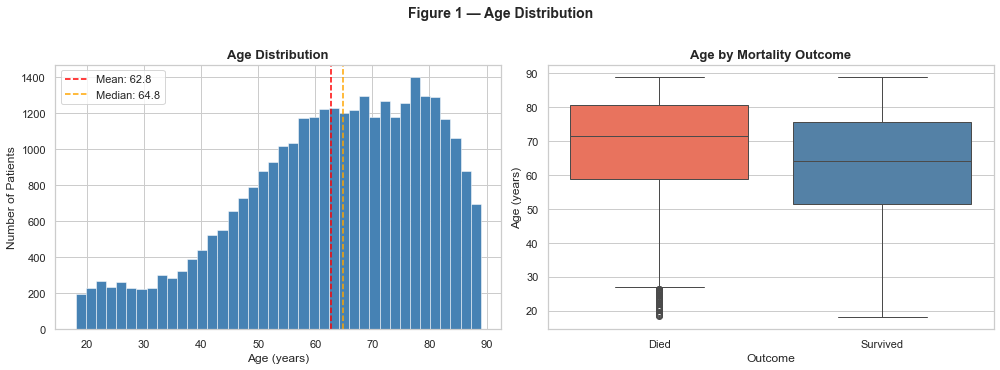

Figure 1 saved


In [3]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(cohort['AGE'], bins=40, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(cohort['AGE'].mean(),   color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: {cohort['AGE'].mean():.1f}")
axes[0].axvline(cohort['AGE'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: {cohort['AGE'].median():.1f}")
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# Age by mortality
cohort['MORTALITY'] = cohort['HOSPITAL_EXPIRE_FLAG'].map({0: 'Survived', 1: 'Died'})
sns.boxplot(data=cohort, x='MORTALITY', y='AGE',
            palette={'Survived': 'steelblue', 'Died': 'tomato'},
            ax=axes[1])
axes[1].set_title('Age by Mortality Outcome', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Age (years)')

plt.suptitle('Figure 1 — Age Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig1_age_distribution.png'),
            bbox_inches='tight')
plt.show()
print("Figure 1 saved")

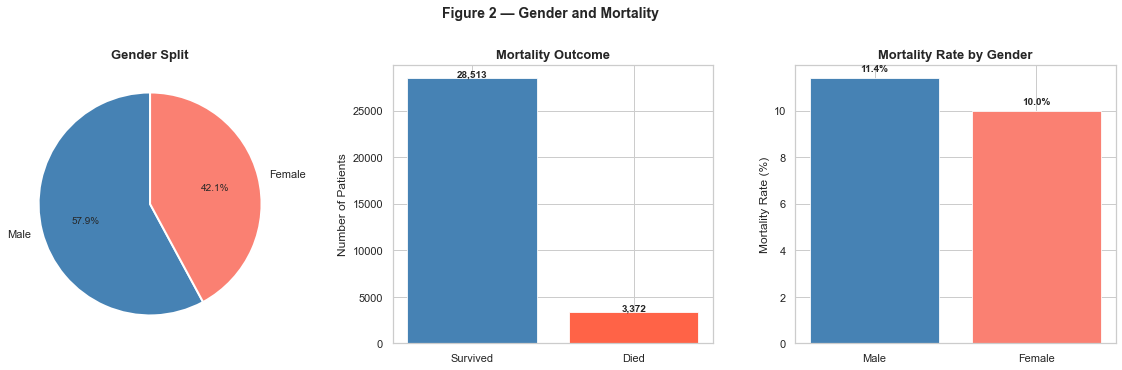

Figure 2 saved


In [4]:
# Gender and mortality breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender split
gender_counts = cohort['GENDER'].value_counts()
axes[0].pie(gender_counts, labels=['Male', 'Female'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Gender Split', fontsize=13, fontweight='bold')

# Mortality count
mort_counts = cohort['MORTALITY'].value_counts()
colors = ['steelblue' if x == 'Survived' else 'tomato' for x in mort_counts.index]
axes[1].bar(mort_counts.index, mort_counts.values, color=colors,
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Mortality Outcome', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for i, v in enumerate(mort_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Mortality rate by gender
mort_by_gender = cohort.groupby('GENDER')['HOSPITAL_EXPIRE_FLAG'].mean() * 100
axes[2].bar(['Male', 'Female'], mort_by_gender.values,
            color=['steelblue', 'salmon'], edgecolor='white', linewidth=0.8)
axes[2].set_title('Mortality Rate by Gender', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Mortality Rate (%)')
for i, v in enumerate(mort_by_gender.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Figure 2 — Gender and Mortality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig2_gender_mortality.png'),
            bbox_inches='tight')
plt.show()
print("Figure 2 saved")

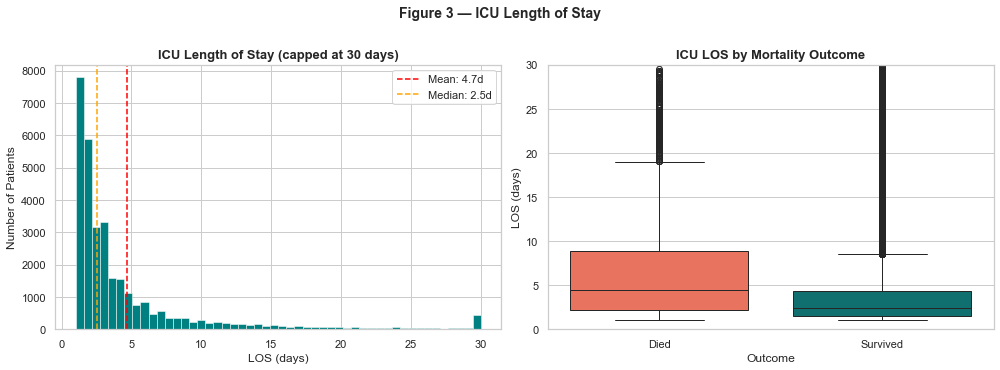

Figure 3 saved


In [5]:
# ICU Length of Stay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clip LOS for display (extreme outliers skew the plot)
los_clipped = cohort['LOS'].clip(upper=30)

# Histogram
axes[0].hist(los_clipped, bins=50, color='teal',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(cohort['LOS'].mean(),   color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {cohort['LOS'].mean():.1f}d")
axes[0].axvline(cohort['LOS'].median(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Median: {cohort['LOS'].median():.1f}d")
axes[0].set_title('ICU Length of Stay (capped at 30 days)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('LOS (days)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# LOS by mortality
sns.boxplot(data=cohort, x='MORTALITY', y='LOS',
            palette={'Survived': 'teal', 'Died': 'tomato'},
            ax=axes[1])
axes[1].set_ylim(0, 30)
axes[1].set_title('ICU LOS by Mortality Outcome', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('LOS (days)')

plt.suptitle('Figure 3 — ICU Length of Stay', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig3_los_distribution.png'),
            bbox_inches='tight')
plt.show()
print("Figure 3 saved")

In [6]:
# Lab value statistics per test
LAB_NAMES = {
    50912: 'creatinine',
    50983: 'sodium',
    50971: 'potassium',
    50882: 'bicarbonate',
    51006: 'bun',
    50931: 'glucose',
    51222: 'haemoglobin',
    51301: 'wbc',
    51265: 'platelets',
    50813: 'lactate',
    50820: 'ph',
    50802: 'base_excess'
}

labs['LAB_NAME'] = labs['ITEMID'].map(LAB_NAMES)

# Summary stats per lab
lab_stats = labs.groupby('LAB_NAME')['VALUENUM'].agg(
    Count='count',
    Mean='mean',
    Std='std',
    Min='min',
    Median='median',
    Max='max'
).round(2)

print("Lab Value Summary Statistics:")
print("=" * 70)
print(lab_stats.to_string())
print("=" * 70)

Lab Value Summary Statistics:
              Count    Mean     Std    Min  Median      Max
LAB_NAME                                                   
base_excess  195329    4.40    3.50   1.00    3.00   162.00
bicarbonate  780439   25.41    4.89   2.00   25.00    90.00
bun          791790   29.26   22.92   1.00   22.00   290.00
creatinine   797192    1.56    1.89   0.05    1.00   808.00
glucose      748834  131.21   66.07   1.00  116.00  3565.00
haemoglobin  752266   10.56    1.96   1.30   10.30    25.50
lactate      187024    2.60    2.55   0.05    1.80    36.00
ph           530655    7.38    0.09   0.94    7.39     7.99
platelets    778163  239.32  150.31   4.00  215.00  4504.00
potassium    845365    4.15    0.66   0.80    4.10    27.50
sodium       808328  138.56    4.95  35.00  139.00   189.00
wbc          752800   10.50    9.01   0.10    9.10   846.70


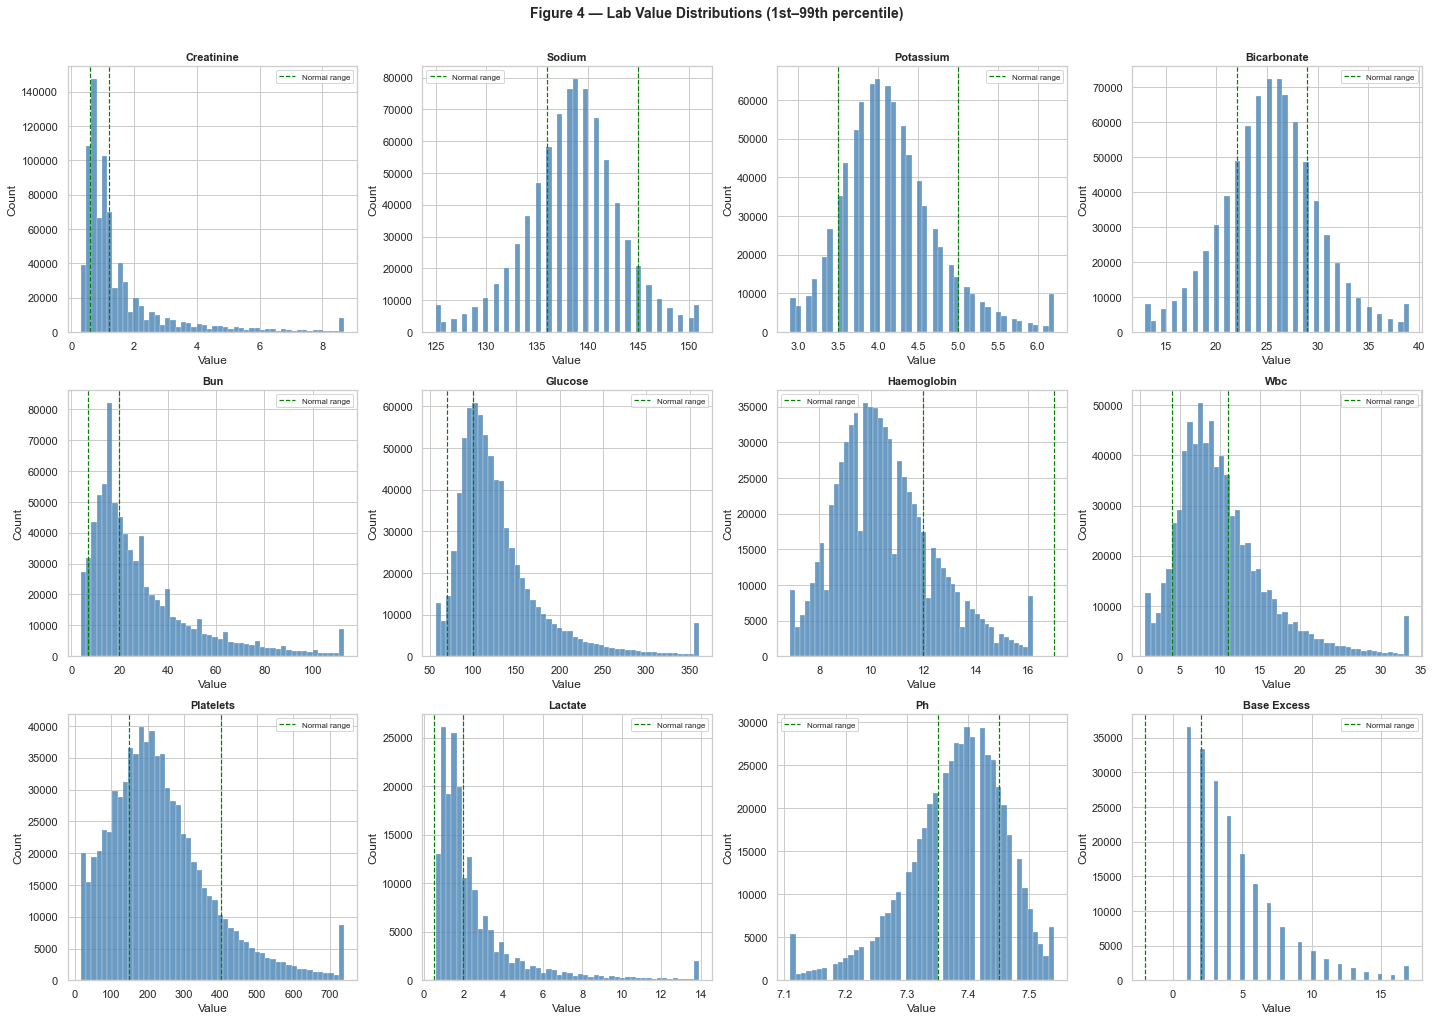

Figure 4 saved


In [7]:
# Lab distributions — one plot per lab
lab_list = list(LAB_NAMES.values())

# Clinical reference ranges for context lines
ref_ranges = {
    'creatinine':  (0.6, 1.2),
    'sodium':      (136, 145),
    'potassium':   (3.5, 5.0),
    'bicarbonate': (22, 29),
    'bun':         (7, 20),
    'glucose':     (70, 100),
    'haemoglobin': (12, 17),
    'wbc':         (4, 11),
    'platelets':   (150, 400),
    'lactate':     (0.5, 2.0),
    'ph':          (7.35, 7.45),
    'base_excess': (-2, 2)
}

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, lab in enumerate(lab_list):
    data = labs[labs['LAB_NAME'] == lab]['VALUENUM']

    # Clip extreme outliers for display only
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data.clip(lower=p1, upper=p99)

    axes[i].hist(data_clipped, bins=50, color='steelblue',
                 edgecolor='white', linewidth=0.3, alpha=0.8)

    # Add reference range lines
    if lab in ref_ranges:
        lo, hi = ref_ranges[lab]
        axes[i].axvline(lo, color='green', linestyle='--',
                        linewidth=1.2, label='Normal range')
        axes[i].axvline(hi, color='green', linestyle='--', linewidth=1.2)

    axes[i].set_title(lab.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 4 — Lab Value Distributions (1st–99th percentile)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig4_lab_distributions.png'),
            bbox_inches='tight')
plt.show()
print("Figure 4 saved")

In [8]:
# Merge labs with cohort and extract first 24hrs

# Keep only labs for patients in our cohort
cohort_labs = labs[labs['HADM_ID'].isin(cohort['HADM_ID'])].copy()

# Merge admission time
cohort_labs = cohort_labs.merge(
    cohort[['HADM_ID', 'ADMITTIME']], on='HADM_ID', how='left'
)

# Compute hours from admission
cohort_labs['HOURS_FROM_ADMIT'] = (
    cohort_labs['CHARTTIME'] - cohort_labs['ADMITTIME']
).dt.total_seconds() / 3600

# Keep only first 24 hours
labs_24h = cohort_labs[
    (cohort_labs['HOURS_FROM_ADMIT'] >= 0) &
    (cohort_labs['HOURS_FROM_ADMIT'] <= 24)
].copy()

print(f"Total lab events in cohort:       {len(cohort_labs):,}")
print(f"Lab events in first 24 hours:     {len(labs_24h):,}")
print(f"Patients with at least one lab:   "
      f"{labs_24h['HADM_ID'].nunique():,}")

Total lab events in cohort:       4,393,974
Lab events in first 24 hours:     649,309
Patients with at least one lab:   31,016


In [9]:
# Pivot labs to wide format (one row per patient)

# Mean value per patient per lab in first 24hrs
labs_pivot = labs_24h.groupby(['HADM_ID', 'LAB_NAME'])['VALUENUM'].mean().unstack()
labs_pivot.columns = [f'lab_{c}' for c in labs_pivot.columns]
labs_pivot = labs_pivot.reset_index()

# Merge with cohort
feature_df = cohort[['SUBJECT_ID', 'HADM_ID', 'AGE', 'GENDER',
                      'LOS', 'HOSPITAL_EXPIRE_FLAG',
                      'ADMISSION_TYPE', 'INSURANCE']].merge(
    labs_pivot, on='HADM_ID', how='left'
)

print(f"Feature matrix shape: {feature_df.shape}")
print(f"\nColumns:\n{list(feature_df.columns)}")
feature_df.head()

Feature matrix shape: (31885, 20)

Columns:
['SUBJECT_ID', 'HADM_ID', 'AGE', 'GENDER', 'LOS', 'HOSPITAL_EXPIRE_FLAG', 'ADMISSION_TYPE', 'INSURANCE', 'lab_base_excess', 'lab_bicarbonate', 'lab_bun', 'lab_creatinine', 'lab_glucose', 'lab_haemoglobin', 'lab_lactate', 'lab_ph', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_wbc']


,SUBJECT_ID,HADM_ID,AGE,GENDER,LOS,HOSPITAL_EXPIRE_FLAG,ADMISSION_TYPE,INSURANCE,lab_base_excess,lab_bicarbonate,lab_bun,lab_creatinine,lab_glucose,lab_haemoglobin,lab_lactate,lab_ph,lab_platelets,lab_potassium,lab_sodium,lab_wbc
0,29156,161773,72.125941,M,9.8777,1,EMERGENCY,Private,4.333333,31.0,8.0,0.40,120.0,8.90,NaN,7.396667,372.0,4.10,137.0,9.40
1,12001,173927,71.627652,F,4.6201,0,EMERGENCY,Medicare,NaN,23.0,7.5,0.65,133.5,12.25,NaN,NaN,250.0,3.55,140.5,10.40
2,21081,159656,33.201916,F,1.1269,0,EMERGENCY,Medicaid,NaN,25.0,14.0,0.90,129.0,10.40,NaN,7.260000,185.0,4.40,138.0,13.50
3,32096,158366,29.522245,F,2.2924,0,EMERGENCY,Private,3.000000,25.0,4.0,0.45,118.0,8.50,0.8,7.416667,219.5,3.75,140.0,5.75
4,20957,113808,48.219028,F,1.9028,0,EMERGENCY,Private,NaN,22.0,17.0,0.10,98.0,8.60,NaN,NaN,324.0,3.70,135.0,15.60


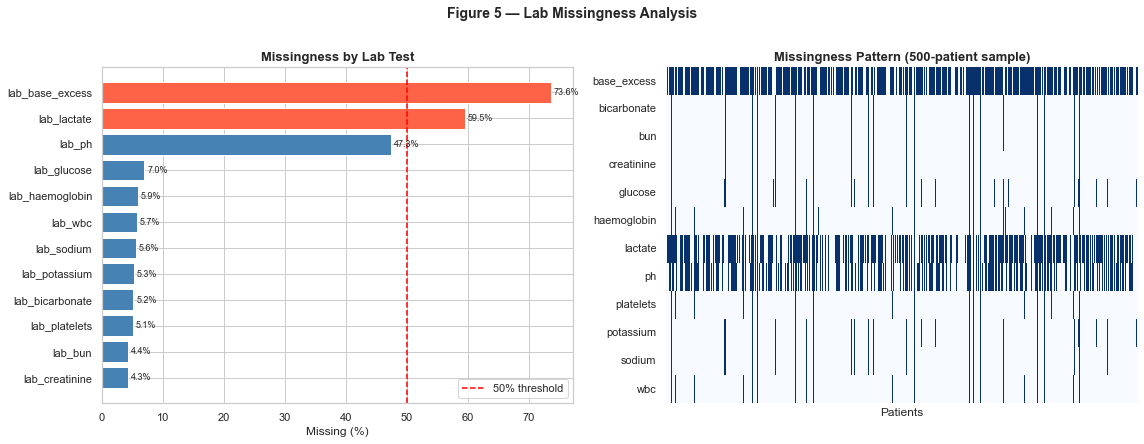


Missingness Summary:
       Lab Test  Missing (%)
 lab_creatinine     4.281010
        lab_bun     4.359417
  lab_platelets     5.061941
lab_bicarbonate     5.187392
  lab_potassium     5.312843
     lab_sodium     5.582562
        lab_wbc     5.714286
lab_haemoglobin     5.896189
    lab_glucose     6.975067
         lab_ph    47.345147
    lab_lactate    59.513878
lab_base_excess    73.589462


In [10]:
# Missingness heatmap

lab_cols = [c for c in feature_df.columns if c.startswith('lab_')]

# Calculate missingness per lab
missing_pct = feature_df[lab_cols].isnull().mean() * 100
missing_df  = missing_pct.reset_index()
missing_df.columns = ['Lab Test', 'Missing (%)']
missing_df = missing_df.sort_values('Missing (%)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of missingness
colors = ['tomato' if x > 50 else 'steelblue' for x in missing_df['Missing (%)']]
axes[0].barh(missing_df['Lab Test'], missing_df['Missing (%)'],
             color=colors, edgecolor='white')
axes[0].axvline(50, color='red', linestyle='--',
                linewidth=1.5, label='50% threshold')
axes[0].set_title('Missingness by Lab Test', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing (%)')
axes[0].legend()
for i, v in enumerate(missing_df['Missing (%)']):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Heatmap on a sample
sample = feature_df[lab_cols].sample(
    min(500, len(feature_df)), random_state=42
)
sns.heatmap(sample.isnull().T, cmap='Blues', cbar=False,
            yticklabels=[c.replace('lab_', '') for c in lab_cols],
            xticklabels=False, ax=axes[1])
axes[1].set_title('Missingness Pattern (500-patient sample)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Patients')

plt.suptitle('Figure 5 — Lab Missingness Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig5_missingness.png'),
            bbox_inches='tight')
plt.show()

print("\nMissingness Summary:")
print(missing_df.to_string(index=False))

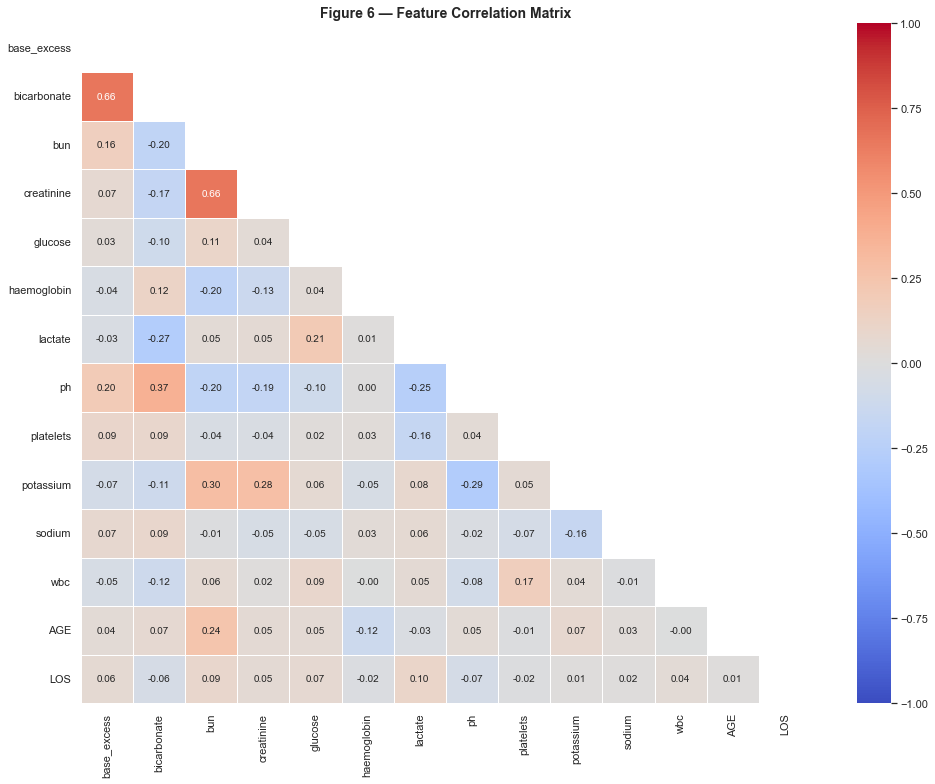

Figure 6 saved


In [11]:
# Correlation between lab features

corr_matrix = feature_df[lab_cols + ['AGE', 'LOS']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            xticklabels=[c.replace('lab_', '') for c in corr_matrix.columns],
            yticklabels=[c.replace('lab_', '') for c in corr_matrix.columns])

ax.set_title('Figure 6 — Feature Correlation Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'fig6_correlation_matrix.png'),
            bbox_inches='tight')
plt.show()
print("Figure 6 saved")

In [12]:
# Save feature matrix
feature_df.to_csv(
    os.path.join(PROCESSED_PATH, 'feature_matrix.csv'), index=False
)

print(f"Feature matrix saved → {PROCESSED_PATH}")
print(f"\nFinal shape:  {feature_df.shape}")
print(f"Patients:     {len(feature_df):,}")
print(f"Features:     {feature_df.shape[1]}")
print(f"\nMissingness summary:")
print(feature_df[lab_cols].isnull().mean().round(3).to_string())

Feature matrix saved → data\processed

Final shape:  (31885, 20)
Patients:     31,885
Features:     20

Missingness summary:
lab_base_excess    0.736
lab_bicarbonate    0.052
lab_bun            0.044
lab_creatinine     0.043
lab_glucose        0.070
lab_haemoglobin    0.059
lab_lactate        0.595
lab_ph             0.473
lab_platelets      0.051
lab_potassium      0.053
lab_sodium         0.056
lab_wbc            0.057


## Notebook 02 — EDA Summary

### Figures Produced
| Figure | Description |
|--------|-------------|
| Fig 1  | Age distribution + age by mortality |
| Fig 2  | Gender split + mortality breakdown  |
| Fig 3  | ICU length of stay distribution     |
| Fig 4  | Lab value distributions (12 tests)  |
| Fig 5  | Missingness analysis                |
| Fig 6  | Feature correlation matrix          |

### Key Findings
- Cohort is adult ICU patients, first admission only
- Mortality rate ~11.5%, consistent with literature
- Lab missingness varies — some tests ordered selectively
- Missingness is clinically informative (not random)